<a href="https://colab.research.google.com/github/alex-jk/YRP-vehicle-accidents/blob/main/yrp_vehicle_accidents_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import YRP data**

In [20]:
from getpass import getpass
TOKEN = getpass('GitHub token: ')

!git clone https://{TOKEN}@github.com/alex-jk/YRP-vehicle-accidents.git
%cd YRP-vehicle-accidents

GitHub token: ··········
Cloning into 'YRP-vehicle-accidents'...
remote: Enumerating objects: 58, done.
remote: Counting objects: 100% (58/58), done.
remote: Compressing objects: 100% (56/56), done.
remote: Total 58 (delta 31), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (58/58), 57.32 KiB | 3.58 MiB/s, done.
Resolving deltas: 100% (31/31), done.
/content/YRP-vehicle-accidents/YRP-vehicle-accidents


In [21]:
import pandas as pd
import re
import matplotlib.pyplot as plt
df = pd.read_csv("data/YRP Data vehicle accidents 2023 - now.csv")

# Parse year
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Year'] = df['Date'].dt.year

# People per row: count items in Age/Gender (comma- or slash-separated); use max; default to 1
def count_items(x):
    if not isinstance(x, str): return 0
    parts = [p.strip() for p in re.split(r'[,/]', x) if p.strip()]
    return len(parts)

age_n    = df['Age'].apply(count_items)
gender_n = df['Gender'].apply(count_items)
person_n = age_n.combine(gender_n, max).where(lambda s: s>0, 1)
# print(person_n)

# Robust Y/N → boolean
is_yes = lambda x: isinstance(x, str) and x.strip().upper().startswith('Y')
mot = df['Motorcycle'].map(is_yes)
ped = df['Pedestrian'].map(is_yes)
cyc = df['Cyclist'].map(is_yes)
mob = df['Mobility Scooter'].map(is_yes)

# Category per row (priority: Pedestrian > Cyclist > Mobility scooter > Other)
def victim_type(mot, ped, cyc, mob):
    if mot: return 'Motorcyclist'
    if ped: return 'Pedestrian'
    if cyc: return 'Cyclist'
    if mob: return 'Mobility Scooter'
    return 'Car'

df['Type'] = [victim_type(m, p, c, b) for m, p, c, b in zip(mot, ped, cyc, mob)]
df['Deaths'] = person_n

print(f"\nDF shape: {df.shape}")
df.head(10)


DF shape: (70, 18)


,ID,Date,Time,Main Street,Main Street 2,Municipality,Intersection,Motorcycle,Age,Gender,Mobility Scooter,Pedestrian,Single Vehicle,Night,Cyclist,Year,Type,Deaths
0,2023_16704,2023-01-14,14:28,McCowan Road,Bur Oak Avenue,Markham,Y,N,75,Female,N,N,N,N,N,2023,Car,1
1,2023_35339,2023-01-30,6:30,9th Line,Bloomington Road,Whitchurch-Stouffville,Y,N,"Adult, Adult","Male, Male",N,N,N,N,N,2023,Car,2
2,2023_87652,2023-03-15,12:49,Highway 48,NaN,Whitchurch-Stouffville,N,N,35,Male,N,Y,N,N,N,2023,Pedestrian,1
3,2023_170962,2023-05-19,23:49,Major MacKenzie Dr W,Jane Street,Vaughan,Y,NaN,NaN,NaN,NaN,Y,NaN,NaN,NaN,2023,Pedestrian,1
4,2023_175551,2023-05-23,18:11,Pine Valley Drive,Major MacKenzie Dr W,Vaughan,Y,N,20,Male,N,Y,N,N,N,2023,Pedestrian,1
5,2023_183025,2023-05-29,7:52,Jane Street,NaN,King,Y,Y,Adult,Male,N,N,N,N,N,2023,Motorcyclist,1
6,2023_189685,2023-06-01,19:21,Pine Valley Drive,NaN,Vaughan,N,N,72,Female,N,N,N,N,N,2023,Car,1
7,2023_238781,2023-07-05,12:22,Dudley Avenue,NaN,Markham,N,NaN,NaN,NaN,NaN,Y,NaN,NaN,NaN,2023,Pedestrian,1
8,2023_265277,2023-07-25,22:15,Highway 7,Thornhill Woods Drive,Vaughan,Y,Y,"45, 47","Male, Female",N,N,N,N,N,2023,Motorcyclist,2
9,2023_269592,2023-07-29,10:23,Keele Street,Sherwood Park Dr,Vaughan,Y,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023,Car,1


**Summarize by year and type**

In [22]:
# Sum people by year & type
counts = (
    df.groupby(['Year','Type'])['Deaths']
      .sum()
      .unstack('Type')
      .fillna(0)
      .astype(int)
      .sort_index()
)

# totals (people) per year
year_totals = df.groupby('Year')['Deaths'].sum()

def gender_counts(cell, deaths):
    # NA/blank → all Unknown
    if not isinstance(cell, str) or not cell.strip():
        return pd.Series({'Male Total': 0, 'Female Total': 0, 'Unknown Total': deaths})
    toks = [t.strip().lower() for t in re.split(r'[,/;|]', cell) if t.strip()]
    m = sum(t.startswith('m') for t in toks)        # M / Male
    f = sum(t.startswith('f') for t in toks)        # F / Female
    other = sum(not (t.startswith('m') or t.startswith('f')) for t in toks)
    u = other + max(0, deaths - (m + f + other))    # any extra people → Unknown
    return pd.Series({'Male Total': m, 'Female Total': f, 'Unknown Total': u})

# row → year totals
totals_cols = ['Male Total','Female Total','Unknown Total']
by_year_gender = (
    pd.concat([df['Year'],
               df.apply(lambda r: gender_counts(r['Gender'], int(r['Deaths'])), axis=1)], axis=1)
      .groupby('Year')[totals_cols].sum()
)

# Make the table tidy, ordered, with totals
nice = counts.copy()

# attach to counts table
for col in ['Male Total','Female Total','Unknown Total']:
    nice[col] = by_year_gender.reindex(nice.index.drop('All years', errors='ignore')).get(col)

# "All years" totals
nice.loc['All years', totals_cols] = by_year_gender.sum().values

# ensure all expected columns exist
select_cols = ['Motorcyclist', 'Pedestrian', 'Cyclist', 'Mobility Scooter', 'Car']
all_cols = select_cols + totals_cols
for col in all_cols:
    if col not in nice.columns:
        nice[col] = 0

# order columns and add totals
nice = nice[all_cols]
nice['Total'] = nice[select_cols].sum(axis=1)

count_cols = select_cols + totals_cols + ['Total']
nice.loc['All years', count_cols] = (
    nice.drop(index='All years', errors='ignore')[count_cols].sum()
)
# ints + a simple style (optional in notebooks)
nice = nice.astype(int)

# pct columns per row
den = (nice[totals_cols].sum(axis=1)).replace(0, pd.NA)
nice['Male %']    = (nice['Male Total']    / den * 100).round(1)
nice['Female %']  = (nice['Female Total']  / den * 100).round(1)
nice['Unknown %'] = (100 - nice['Male %'] - nice['Female %']).round(1)

nice.style.set_caption("Fatalities by Year and Victim Type") \
          .set_table_styles([{'selector': 'caption', 'props': [('font-weight', 'bold')]}]) \
          .format('{:,}')

Type,Motorcyclist,Pedestrian,Cyclist,Mobility Scooter,Car,Male Total,Female Total,Unknown Total,Total,Male %,Female %,Unknown %
Year,,,,,,,,,,,,
2023,5,9,0,0,9,11,7,5,23,47.8,30.4,21.8
2024,5,8,1,1,13,22,5,1,28,78.6,17.9,3.5
2025,3,6,1,0,11,12,5,4,21,57.1,23.8,19.1
All years,13,23,2,1,33,45,17,10,72,62.5,23.6,13.9


**Summary by gender and type**

In [23]:
by_type_gender = (
    pd.concat([df['Type'],
               df.apply(lambda r: gender_counts(r['Gender'], int(r['Deaths'])), axis=1)], axis=1)
      .groupby('Type')[totals_cols].sum()
).reindex(select_cols, fill_value=0)

# add totals and percents
by_type_gender['Total'] = by_type_gender[totals_cols].sum(axis=1)
percent_cols = [c.replace('Total', '%') for c in totals_cols]
for tcol, pcol in zip(totals_cols, percent_cols):
    by_type_gender[pcol] = (by_type_gender[tcol] / by_type_gender['Total'] * 100).round(1)

# tidy order
ordered_cols = totals_cols + ['Total'] + percent_cols
tbl_disp = by_type_gender[ordered_cols].copy()
tbl_disp[totals_cols + ['Total']] = tbl_disp[totals_cols + ['Total']].astype(int)

# nice display
tbl_disp.style.set_caption("By Type — Gender Totals and %") \
    .set_table_styles([{'selector': 'caption', 'props': [('font-weight','bold')]}]) \
    .format({**{c: '{:,}' for c in totals_cols + ['Total']},
             **{c: '{:.1f}%' for c in percent_cols}})

,Male Total,Female Total,Unknown Total,Total,Male %,Female %,Unknown %
Type,,,,,,,
Motorcyclist,11,2,0,13,84.6%,15.4%,0.0%
Pedestrian,14,6,3,23,60.9%,26.1%,13.0%
Cyclist,2,0,0,2,100.0%,0.0%,0.0%
Mobility Scooter,1,0,0,1,100.0%,0.0%,0.0%
Car,17,9,7,33,51.5%,27.3%,21.2%


**Summary by age group and type**

In [24]:
def age_bucket_counts(cell, deaths):
    out = {'Under 20': 0, 'Adult': 0, '60+': 0, 'Age Unknown': 0}
    if not isinstance(cell, str) or not cell.strip():
        out['Age Unknown'] = deaths; return pd.Series(out)
    toks = [t.strip() for t in re.split(r'[,/;|]', cell) if t.strip()]
    for t in toks:
        tl = t.lower()
        if tl == 'adult': out['Adult'] += 1
        elif tl == 'youth': out['Under 20'] += 1
        elif tl in {'na','n/a','unknown'}: out['Age Unknown'] += 1
        elif tl == '60+': out['60+'] += 1
        else:
            digits = re.sub(r'[^\d]', '', tl)
            if digits:
                n = int(digits)
                out['60+' if n>=60 else 'Adult' if n>=20 else 'Under 20'] += 1
            else:
                out['Age Unknown'] += 1
    missing = max(0, deaths - sum(out.values()))
    if missing: out['Age Unknown'] += missing
    return pd.Series(out)

age_cols = ['Under 20', 'Adult', '60+', 'Age Unknown']

# aggregate by Type
by_type_age = (
    pd.concat([df['Type'],
               df.apply(lambda r: age_bucket_counts(r['Age'], int(r['Deaths'])), axis=1)], axis=1)
      .groupby('Type')[age_cols].sum()
).reindex(select_cols, fill_value=0)

# counts + percents
by_type_age['Total'] = by_type_age[age_cols].sum(axis=1)
pct_cols = [f"{c} %" for c in age_cols]
by_type_age[pct_cols] = (by_type_age[age_cols].div(by_type_age['Total'], axis=0)*100).round(1)

# ---- bottom totals row ----
tot_counts = by_type_age[age_cols].sum()
tot_total  = int(tot_counts.sum())
tot_pcts   = (tot_counts / tot_total * 100).round(1)
by_type_age.loc['All types', age_cols] = tot_counts.values
by_type_age.loc['All types', 'Total']  = tot_total
by_type_age.loc['All types', pct_cols] = tot_pcts.values

# tidy display
ordered_cols = age_cols + ['Total'] + pct_cols

tbl = by_type_age[ordered_cols].copy()
tbl[age_cols + ['Total']] = tbl[age_cols + ['Total']].astype(int)

styles = [
    {'selector': 'caption',   'props': [('font-weight','bold')]},
    {'selector': 'thead th',  'props': [('background','#f0f0f0'),
                                        ('border-right','1px solid #ddd'),
                                        ('border-bottom','2px solid #999'),
                                        ('padding','6px 8px')]},
    {'selector': 'td',        'props': [('border-right','1px solid #eee')]}
]

tbl.style.set_caption("By Type — Age Buckets (counts and %)") \
    .set_table_styles(styles) \
    .format({**{c: '{:,}' for c in age_cols + ['Total']},
             **{c: '{:.1f}%' for c in pct_cols}})

,Under 20,Adult,60+,Age Unknown,Total,Under 20 %,Adult %,60+ %,Age Unknown %
Type,,,,,,,,,
Motorcyclist,2,11,0,0,13,15.4%,84.6%,0.0%,0.0%
Pedestrian,4,7,9,3,23,17.4%,30.4%,39.1%,13.0%
Cyclist,1,1,0,0,2,50.0%,50.0%,0.0%,0.0%
Mobility Scooter,0,0,1,0,1,0.0%,0.0%,100.0%,0.0%
Car,4,15,9,5,33,12.1%,45.5%,27.3%,15.2%
All types,11,34,19,8,72,15.3%,47.2%,26.4%,11.1%


**Count by Street / Road**

In [25]:
def norm_street(s):
    if not isinstance(s, str): return None
    s = s.strip()
    if s.upper() in {"NA", "N/A", ""}: return None
    s = re.sub(r"\s+", " ", s)  # collapse spaces
    # drop trailing direction tokens (… E/W/N/S or East/West/North/South)
    s = re.sub(r"\b(?:N|S|E|W|North|South|East|West)\b\.?$", "", s, flags=re.IGNORECASE).strip()
    return s.title()

# stack both street columns with the row's Deaths
streets = pd.DataFrame({
    "Street": pd.concat([df["Main Street"], df["Main Street 2"]], ignore_index=True),
    "Deaths": pd.concat([df["Deaths"],       df["Deaths"]],       ignore_index=True),
}).dropna(subset=["Street"])

streets["Street"] = streets["Street"].apply(norm_street)
streets = streets.dropna(subset=["Street"])

deaths_by_street = (streets
    .groupby("Street", as_index=False)["Deaths"].sum()
    .sort_values("Deaths", ascending=False))

# show ALL rows in the output cell
pd.set_option('display.max_rows', None)
deaths_by_street


,Street,Deaths
39,Jane Street,11
48,Major Mackenzie Dr,7
34,Highway 7,6
30,Highway 27,4
7,9Th Line,3
57,Pine Valley Drive,3
24,Dufferin Street,3
20,Davis Drive,3
51,Mccowan Road,3
78,Yonge Street,3


In [26]:
# rural patterns: Concession, Conc, Sideroad/Side Rd/SDRD, Line, Townline
# non-capturing groups → no warning
rural_re = r"\b(?:conc(?:ession)?|side\s*(?:road|rd)|sideroad|sdrd|line|town\s*line|townline)\b"
is_rural = streets["Street"].str.contains(rural_re, regex=True, case=False, na=False)

rural_total = streets.loc[is_rural, "Deaths"].sum()
nonrural_total = streets.loc[~is_rural, "Deaths"].sum()

print("Rural roads total deaths:", int(rural_total))

# unique rural road names (normalized), with optional totals
rural_names = (streets.loc[is_rural, 'Street']
               .str.strip().str.title().dropna().unique())
print(f"Unique rural road names ({len(rural_names)}):")
print("\n".join(sorted(rural_names)))

Rural roads total deaths: 14
Unique rural road names (9):
10Th Concession Road
11Th Concession Road
17Th Sideroad
18Th Sideroad
2Nd Concession Road
8Th Concession Road
9Th Line
Bethesda Sideroad
Queensville Sideroad


**By Intersection (Y/N) and Type**

In [31]:
import pandas as pd

# Intersections (normalize both streets, only Intersection == 'Y')
ints = df[df['Intersection'].astype(str).str.upper().str.startswith('Y')].copy()
ints['A'] = df['Main Street'].apply(norm_street)
ints['B'] = df['Main Street 2'].apply(norm_street)
ints = ints.dropna(subset=['A','B'])
ints['IntersectionName'] = ints[['A','B']].apply(lambda r: ' & '.join(sorted(r)), axis=1)

# 1) Intersections with multiple fatalities (sum of Deaths >= 2)
multi_intersections = (
    ints.groupby('IntersectionName', as_index=False)['Deaths'].sum()
        .query('Deaths >= 2')
        .sort_values('Deaths', ascending=False)
)

# (optional) type breakdown for those intersections (uses your existing df['Type'])
multi_type = (
    ints[ints['IntersectionName'].isin(multi_intersections['IntersectionName'])]
        .pivot_table(index='IntersectionName', columns='Type', values='Deaths',
                     aggfunc='sum', fill_value=0)
        .sort_values(by='IntersectionName')
)

# 2) Jane Street: where did they occur (Jane & what?) and by type
import pandas as pd

select_street = 'Major Mackenzie Dr'  # change as needed

# use your existing normalizer
tmp = df.copy()
tmp['A'] = tmp['Main Street'].apply(norm_street)
tmp['B'] = tmp['Main Street 2'].apply(norm_street)

# rows where the selected street appears in either column
ss = tmp[(tmp['A'] == select_street) | (tmp['B'] == select_street)].copy()

# label as intersection (with the other street) or midblock
def place(r):
    inter = isinstance(r['Intersection'], str) and r['Intersection'].strip().upper().startswith('Y')
    a, b = r['A'], r['B']
    if inter and pd.notna(a) and pd.notna(b):
        other = b if a == select_street else a
        return f"{select_street} & {other}" if other and other != select_street else f"{select_street} (midblock)"
    return f"{select_street} (midblock)"

ss['Location'] = ss.apply(place, axis=1)

# totals by place (includes intersections and midblock)
select_street_df = (
    ss.groupby('Location', as_index=False)['Deaths'].sum()
      .sort_values('Deaths', ascending=False)
)

# breakdown by victim type (assumes df['Type'] exists)
select_street_types = (
    ss.pivot_table(index='Location', columns='Type', values='Deaths',
                   aggfunc='sum', fill_value=0)
      .loc[select_street_df['Location']]
)

print("\nIntersections with more than one accident")
display(multi_intersections)
print("\n----------------------------")
print("\nIntersections with more than one accident by Type")
display(multi_type)
print("\n----------------------------")
display(select_street_df)
print("\n----------------------------")
display(select_street_types)


Intersections with more than one accident


,IntersectionName,Deaths
7,9Th Line & Bloomington Road,2
14,Bur Oak Avenue & Mccowan Road,2
23,Dufferin Street & Major Mackenzie Dr,2
36,Highway 7 & Thornhill Woods Drive,2



----------------------------

Intersections with more than one accident by Type


Type,Car,Motorcyclist,Pedestrian
IntersectionName,,,
9Th Line & Bloomington Road,2,0,0
Bur Oak Avenue & Mccowan Road,1,0,1
Dufferin Street & Major Mackenzie Dr,1,0,1
Highway 7 & Thornhill Woods Drive,0,2,0



----------------------------


,Location,Deaths
0,Major Mackenzie Dr & Dufferin Street,2
1,Major Mackenzie Dr & Highway 27,1
2,Major Mackenzie Dr & Jane Street,1
3,Major Mackenzie Dr & Pine Valley Drive,1
4,Major Mackenzie Dr & Reesor Road,1
5,Major Mackenzie Dr & Vellore Park Avenue,1



----------------------------


Type,Car,Motorcyclist,Pedestrian
Location,,,
Major Mackenzie Dr & Dufferin Street,1,0,1
Major Mackenzie Dr & Highway 27,1,0,0
Major Mackenzie Dr & Jane Street,0,0,1
Major Mackenzie Dr & Pine Valley Drive,0,0,1
Major Mackenzie Dr & Reesor Road,0,1,0
Major Mackenzie Dr & Vellore Park Avenue,0,0,1


**Pedestrian Fatalities and Time of Day**

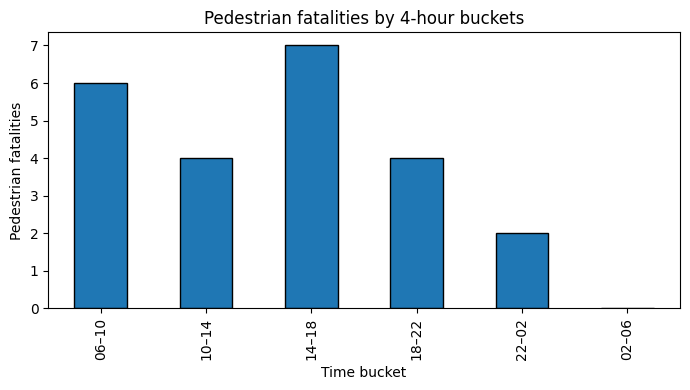

,count
Time bucket,
06–10,6
10–14,4
14–18,7
18–22,4
22–02,2
02–06,0


In [28]:
# Pedestrian fatalities only
ped = df[df['Pedestrian'].astype(str).str.upper().str.startswith('Y')].copy()

# Parse 24h time -> hour
ped['Hour'] = pd.to_datetime(ped['Time'], format='%H:%M', errors='coerce').dt.hour
ped = ped.dropna(subset=['Hour'])

# 4-hour buckets anchored at 06:00: 06–10, 10–14, 14–18, 18–22, 22–02, 02–06
labels = ['06–10','10–14','14–18','18–22','22–02','02–06']
bucket_idx = ((ped['Hour'].astype(int) - 6) % 24) // 4
ped['Time bucket'] = bucket_idx.map(dict(enumerate(labels)))

# Counts (ordered) and plot
counts = ped['Time bucket'].value_counts().reindex(labels, fill_value=0)

plt.figure(figsize=(7,4))
counts.plot(kind='bar', edgecolor='black')
plt.ylabel('Pedestrian fatalities')
plt.title('Pedestrian fatalities by 4-hour buckets')
plt.tight_layout()
plt.show()

counts